# Imports

In [60]:
import logging, warnings; logging.getLogger().setLevel(logging.ERROR);
warnings.filterwarnings("ignore")

import scanpy as sc
import scanpy.external as sce
import numpy as np
import pandas as pd
import re
from pathlib import Path 

import warnings, scipy.sparse as sp, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.pyplot import rc_context
import matplotlib.font_manager
import matplotlib.lines as lines


pd.set_option('display.max_rows', 200)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rc('font', size=12)

sc.settings.n_jobs=-1
sc.set_figure_params(dpi=80, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.settings.figdir = '../../1_outputs/0_figures'
sc.settings.verbosity = 1 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

In [15]:
# preset color palettes and color maps
user_defined_palette =  [ '#F6222E', '#16FF32', '#3283FE', '#FEAF16', '#BDCDFF', '#3B00FB', '#1CFFCE', '#C075A6', '#F8A19F', '#B5EFB5', '#FBE426', '#C4451C', 
                          '#2ED9FF', '#c1c119', '#8b0000', '#FE00FA', '#1CBE4F', '#1C8356', '#0e452b', '#AA0DFE', '#B5EFB5', '#325A9B', '#90AD1C']

user_defined_cmap_markers = LinearSegmentedColormap.from_list('mycmap', ["#E6E6FF", "#CCCCFF", "#B2B2FF", "#9999FF",  "#6666FF",   "#3333FF", "#0000FF"])
user_defined_cmap_degs = LinearSegmentedColormap.from_list('mycmap', ["#0000FF", "#3333FF", "#6666FF", "#9999FF", "#B2B2FF", "#CCCCFF", "#E6E6FF", "#E6FFE6", "#CCFFCC", "#B2FFB2", "#99FF99", "#66FF66", "#33FF33", "#00FF00"])

In [16]:
pwd

'/Users/mkaur/github/2_tff1/1_pyzone/3_figures'

In [61]:
file_outputs = '../1_outputs/' 
h5ad = '../4_h5ad/'
figures = '../1_outputs/0_figures/'

In [36]:
## read in h5ad 

adata = sc.read_h5ad(h5ad + "8_tregs.h5ad")
adata


AnnData object with n_obs × n_vars = 10273 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tissue_colors', 'tissues_ordered_colors', 'treg_celltypes_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_data'
    obsp: 'connectivities', 'distances'

In [19]:
thymus = sc.read_h5ad(h5ad + "9_thymus_tregs.h5ad")
thymus

AnnData object with n_obs × n_vars = 3427 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden_0.2', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'log1p', 'neighbors', 'pca'

In [20]:
spleen = sc.read_h5ad(h5ad + "10_spleen_tregs.h5ad")
spleen

AnnData object with n_obs × n_vars = 3027 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden_0.3', 'hvg', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'tissue_colors', 'tissues_ordered_colors', 'treg_celltypes_colors', 'umap'
    obsm: 'X_pca',

In [21]:
bm = sc.read_h5ad(h5ad + "11_bm_tregs.h5ad")
bm

AnnData object with n_obs × n_vars = 2213 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden_0.2', 'hvg', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'log1p', 'neighbors'

In [22]:
liver = sc.read_h5ad(h5ad + "12_liver_tregs.h5ad")
liver

AnnData object with n_obs × n_vars = 649 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden_0.1', 'hvg', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'log1p', 'neighbors',

In [23]:
lung = sc.read_h5ad(h5ad + "13_lung_tregs.h5ad")
lung

AnnData object with n_obs × n_vars = 172 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden_0.5', 'hvg', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'log1p', 'neighbors',

In [24]:
skin = sc.read_h5ad(h5ad + "14_skin_tregs.h5ad")
skin

AnnData object with n_obs × n_vars = 785 × 23867
    obs: 'condition', 'tissue', 'sample', 'cell_type', 'tissues_ordered', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'treg_celltypes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden_0.4', 'hvg', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'log1p', 'neighbors',

# UMAPs

## Tissues

In [25]:
adata.obs['tissue'].value_counts()

tissue
thymus    3427
spleen    3027
bm        2213
skin       785
liver      649
lung       172
Name: count, dtype: int64

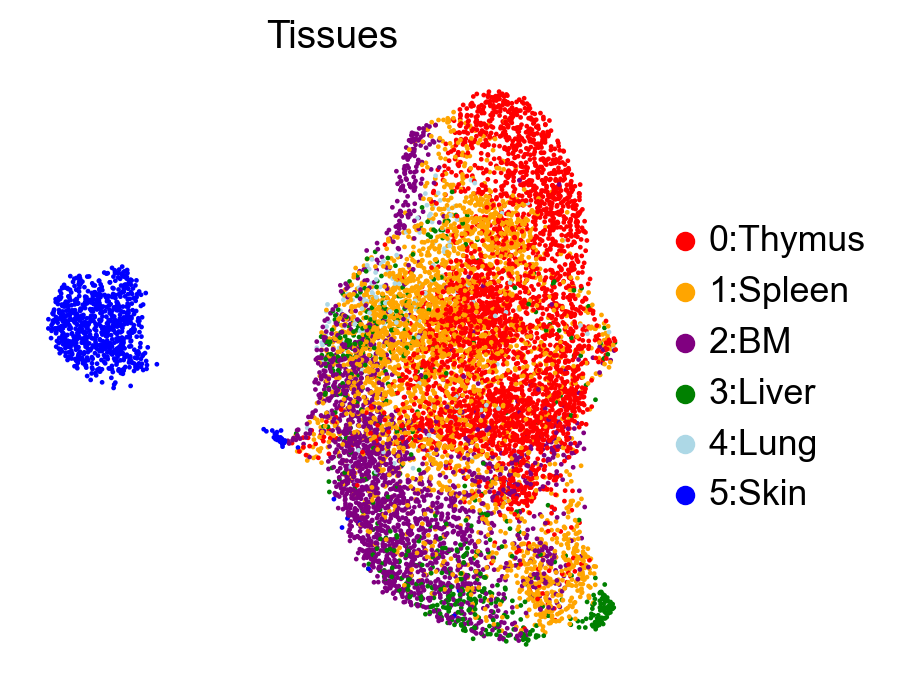

In [42]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=['tissues_ordered'],   
    palette = ['Red', 'Orange', 'Purple', 'Green', 'LightBlue', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Tissues',
    save = '_tissues.pdf'
)

## Regenerative and Suppressive

### Overall

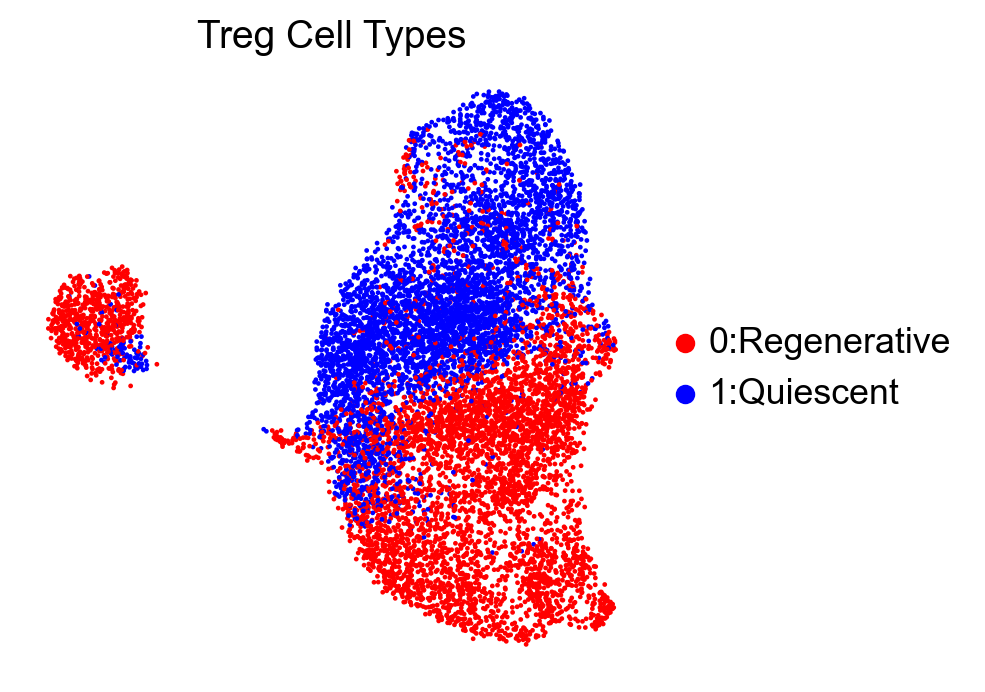

In [37]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Treg Cell Types',
    save = '_treg_celltypes.pdf'
)

### Thymus 

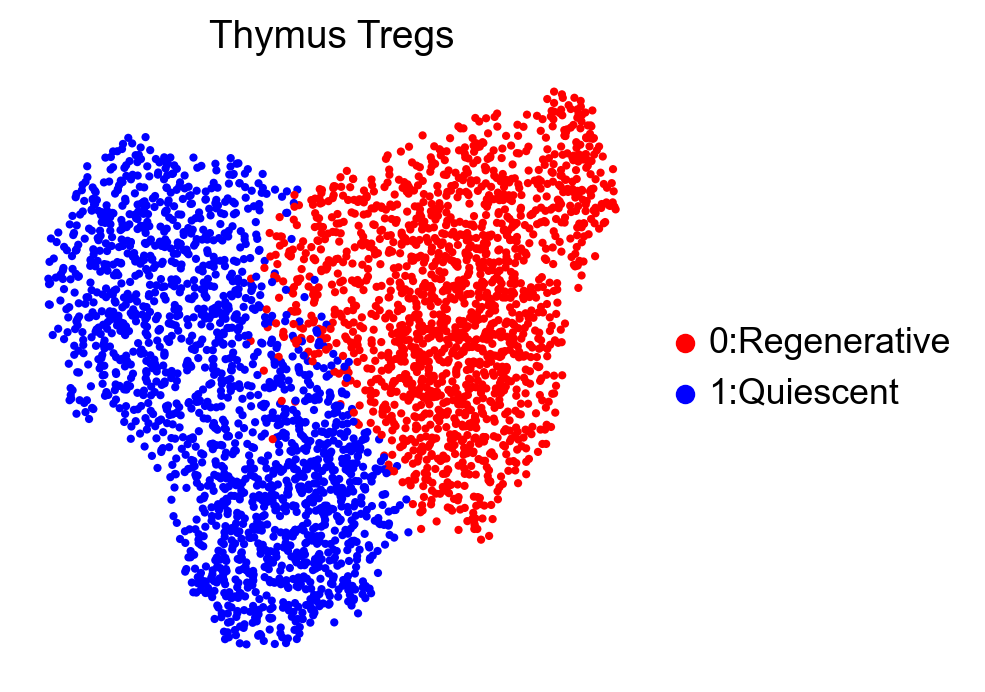

In [27]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    thymus, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Thymus Tregs',
    save = '_thymus_tregs.pdf'
)

### Spleen

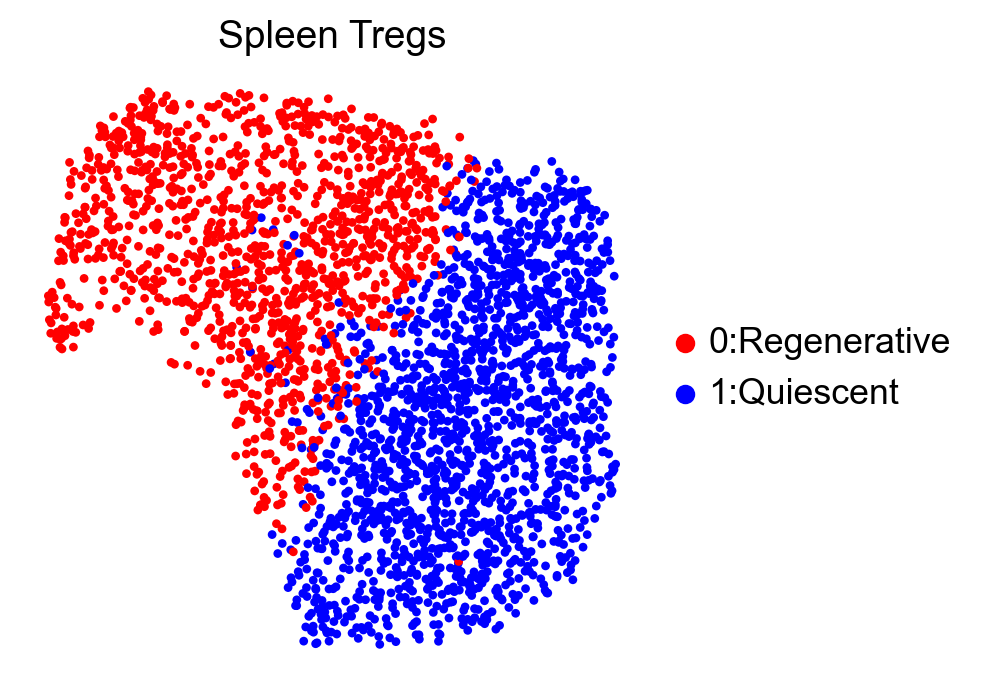

In [28]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    spleen, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Spleen Tregs',
    save = '_spleen_tregs.pdf'
)

### BM

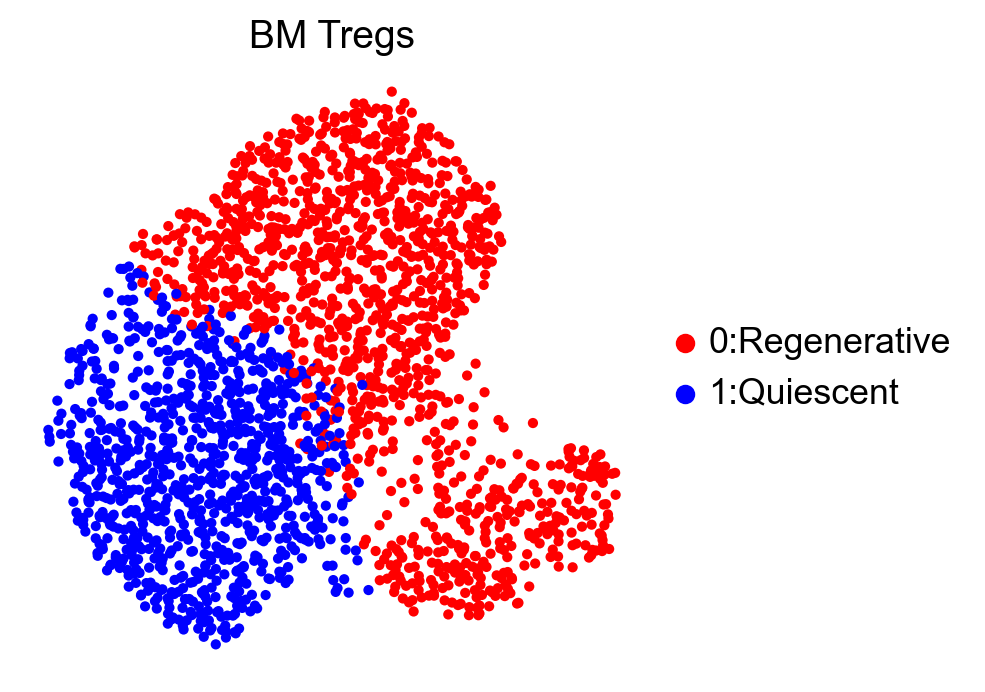

In [29]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    bm, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'BM Tregs',
    save = '_bm_tregs.pdf'
)

### Liver

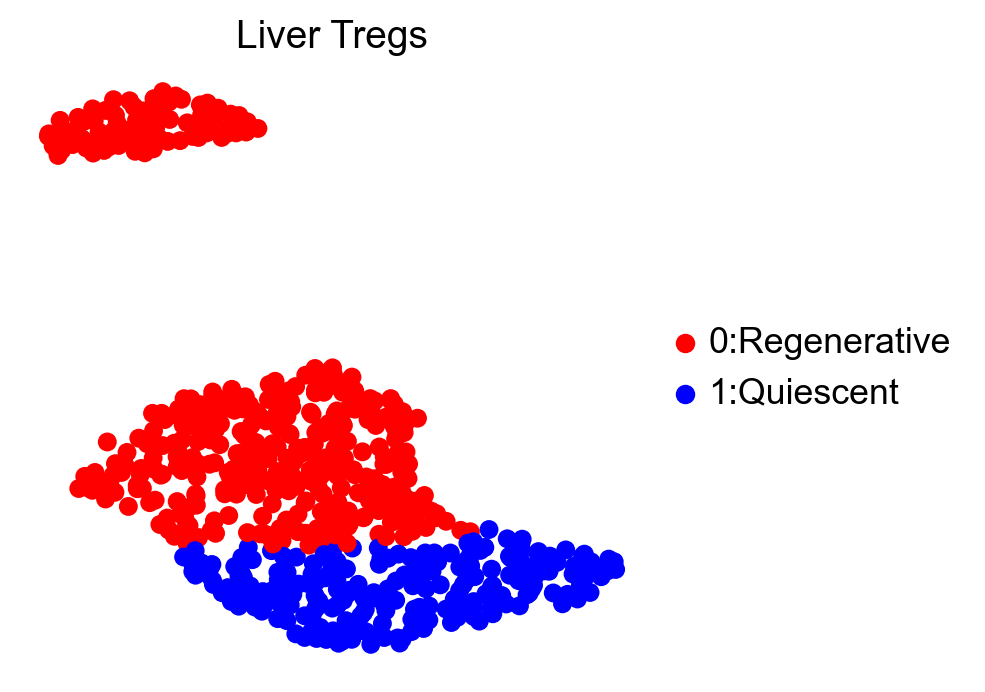

In [30]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    liver, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Liver Tregs',
    save = '_liver_tregs.pdf'
)

### Lung

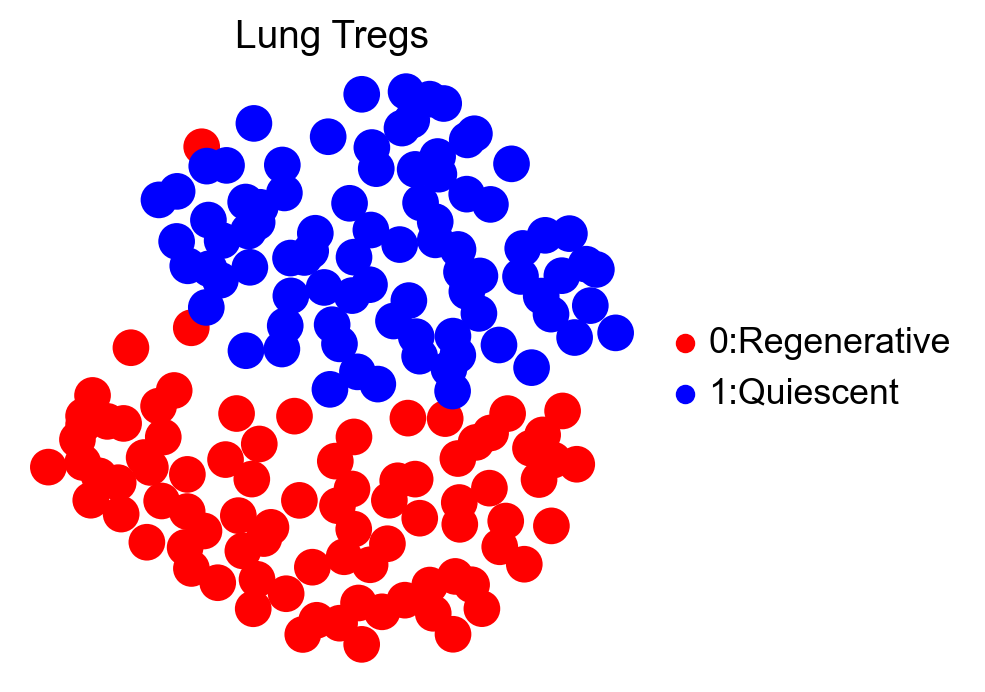

In [31]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    lung, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Lung Tregs',
    save = '_lung_tregs.pdf'
)

### Skin

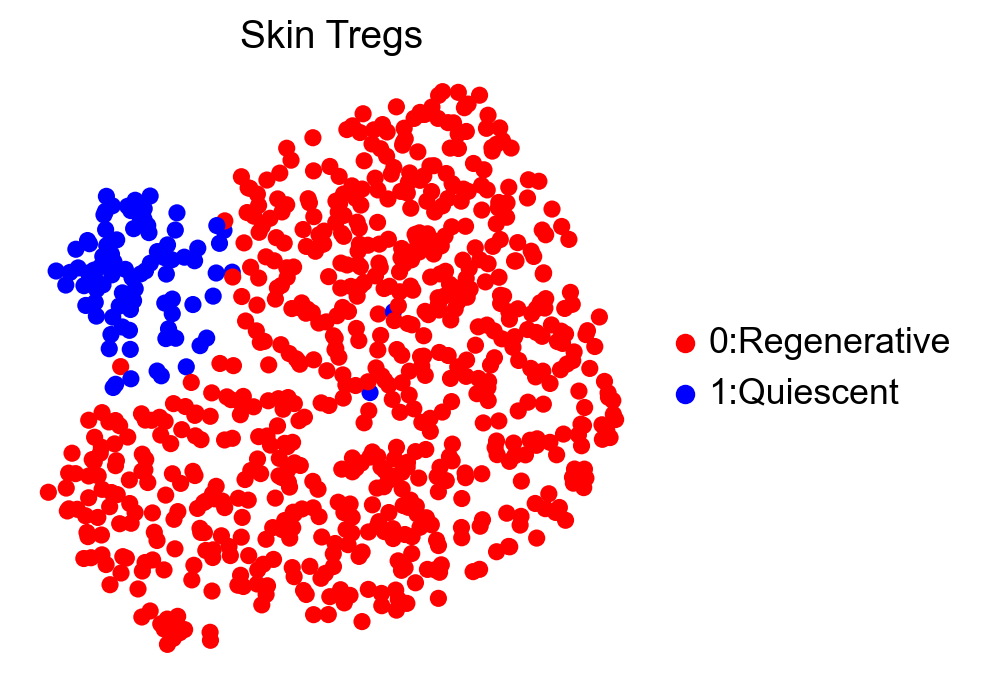

In [32]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    skin, 
    color=['treg_celltypes'],   
    palette = ['Red', 'Blue'], 
    use_raw=False,
    ncols=3,
    wspace = 0.5,
    frameon=False,
    sort_order = False, 
    title = 'Skin Tregs',
    save = '_skin_tregs.pdf'
)

# Frequency Plot

In [62]:
crosstb = pd.crosstab(
    adata.obs['treg_celltypes'],
    adata.obs['tissues_ordered'],
    normalize='index'
) * 100

In [63]:
crosstb

tissues_ordered,0:Thymus,1:Spleen,2:BM,3:Liver,4:Lung,5:Skin
treg_celltypes,,,,,,
0:Regenerative,30.649981,23.197609,23.739260,7.807247,1.606276,12.999626
1:Quiescent,36.308193,36.287863,19.150234,4.696076,1.748323,1.809311


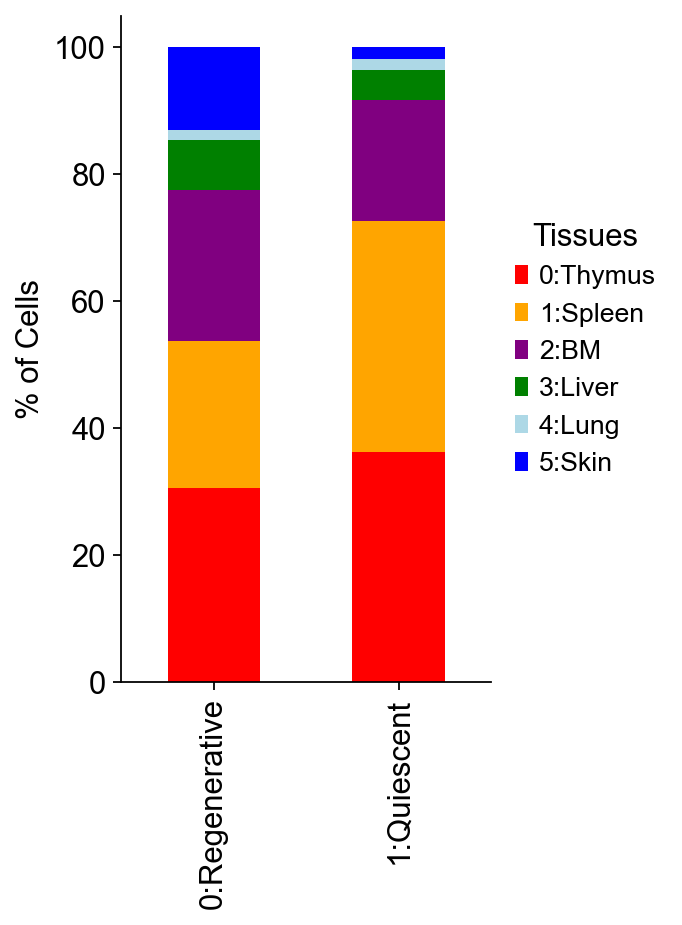

In [65]:
order = ['0:Regenerative', '1:Quiescent']
crosstb = crosstb.reindex(order)

with rc_context({'figure.figsize': (4.5, 6)}):
    ax = crosstb.plot(
        kind='bar', 
        stacked=True,  
        edgecolor="none", 
        color=adata.uns['tissues_ordered_colors'],
        legend=True  # if you don't want the legend
    )
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::1], 
              labels[::1], 
              loc='center left', 
              bbox_to_anchor=(1.0, 0.5), 
              prop={'size': 12},
              frameon=False,
              title='Tissues'
              )
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("% of Cells")

    # remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(figures + 'frequency_plot_treg_celltypes.pdf', dpi=300, bbox_inches = 'tight')

# Matrix Plot

In [33]:
genes = [
    "Tff1", "Penk", "Vegfc", "Hgf", "Il16", "Dtx1", "Batf", "Cxcl12", "Tbx21",
    "Alb", "Gata3", "Rora", "Areg", "Itgav", "Itgae", "Il10", "Jag1", "Sparc", "Tgfb1"
]


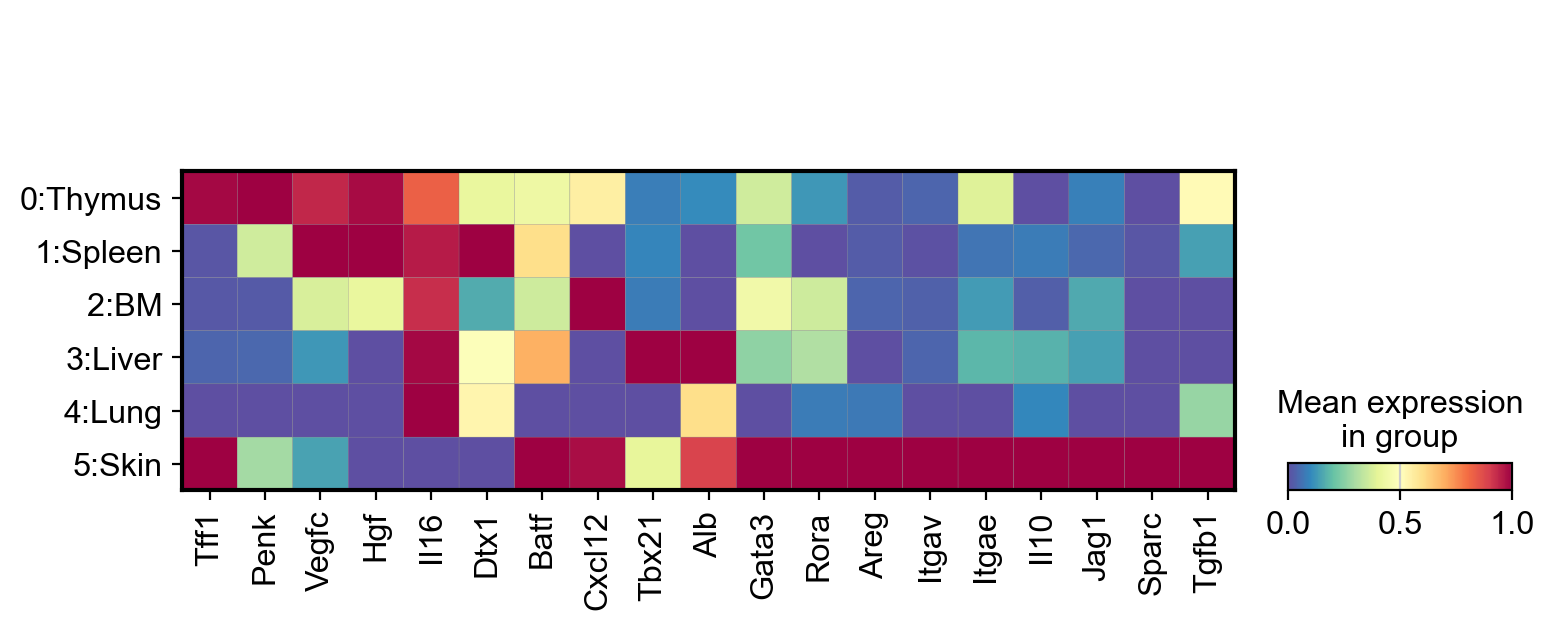

In [34]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.matrixplot(
    adata,
    genes,
    "tissues_ordered",
    cmap="Spectral_r",
    standard_scale="var",
    save='genes_of_interest.pdf',
    use_raw=False
)